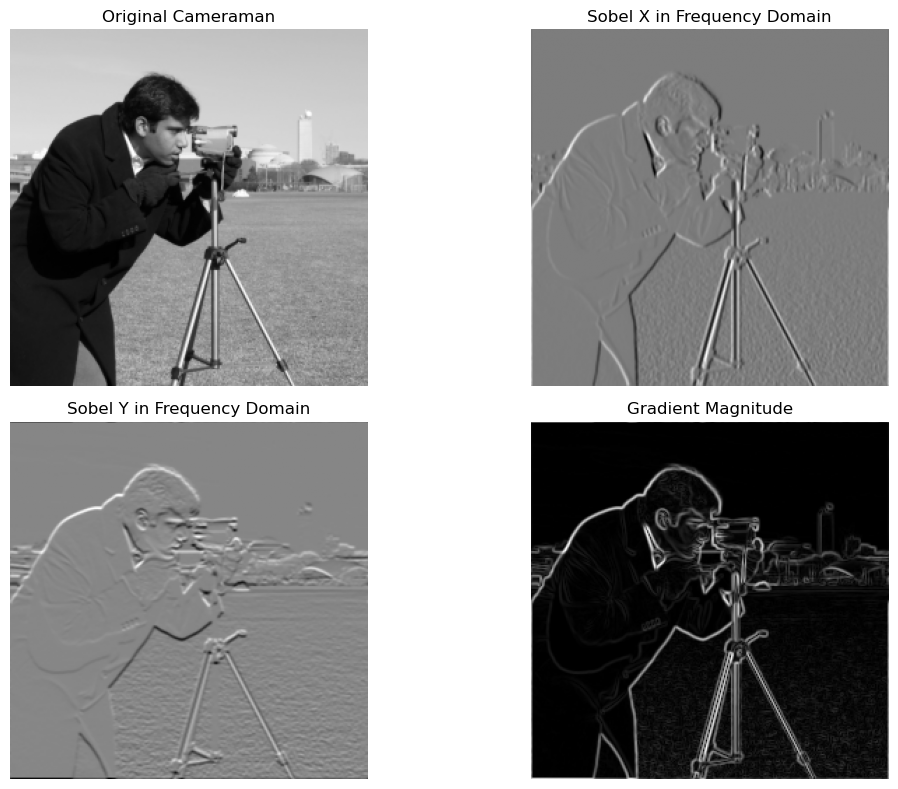

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from scipy.fft import fft2, ifft2, ifftshift

img = data.camera()
img = transform.resize(img, (256, 256), anti_aliasing=True)

sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    cy, cx = ph // 2, pw // 2
    padded[cy - kh//2:cy - kh//2 + kh, cx - kw//2:cx - kw//2 + kw] = kernel
    return fft2(ifftshift(padded))

F = fft2(img)

Hx = center_embed_kernel(sobel_x, img.shape)
Hy = center_embed_kernel(sobel_y, img.shape)

Gx = F * Hx
Gy = F * Hy

img_sobel_x = np.real(ifft2(Gx))
img_sobel_y = np.real(ifft2(Gy))

img_magnitude = np.sqrt(img_sobel_x**2 + img_sobel_y**2)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img_sobel_x, cmap='gray')
plt.title('Sobel X in Frequency Domain')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(img_sobel_y, cmap='gray')
plt.title('Sobel Y in Frequency Domain')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(img_magnitude, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()